In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os
import seaborn as sns

In [2]:
station_metadata_path  = '/mnt/c/Users/tanbi/Downloads/d04_text_meta_2025_10_16.txt'
print(os.path.exists(station_metadata_path))
st_mtdta_df = pd.read_csv(station_metadata_path, sep='\t')

True


In [3]:
st_mtdta_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3855 entries, 0 to 3854
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         3855 non-null   int64  
 1   Fwy        3855 non-null   int64  
 2   Dir        3855 non-null   str    
 3   District   3855 non-null   int64  
 4   County     3855 non-null   int64  
 5   City       2923 non-null   float64
 6   State_PM   3855 non-null   str    
 7   Abs_PM     3855 non-null   float64
 8   Latitude   3855 non-null   float64
 9   Longitude  3855 non-null   float64
 10  Length     2262 non-null   float64
 11  Type       3855 non-null   str    
 12  Lanes      3855 non-null   int64  
 13  Name       3850 non-null   str    
 14  User_ID_1  3855 non-null   str    
 15  User_ID_2  3855 non-null   str    
 16  User_ID_3  3854 non-null   str    
 17  User_ID_4  3855 non-null   int64  
dtypes: float64(5), int64(6), str(7)
memory usage: 542.2 KB


In [4]:
st_mtdta_df.head()

,ID,Fwy,Dir,District,County,City,State_PM,Abs_PM,Latitude,Longitude,Length,Type,Lanes,Name,User_ID_1,User_ID_2,User_ID_3,User_ID_4
0,400000,101,S,4,41,52582.0,19.23,459.835,38.081498,-122.547963,0.415,ML,4,SR-37 conn-s-diag,DT5A2,L4-S-27-101-01923,101482,424150
1,400001,101,N,4,85,68000.0,38.26,387.897,37.364085,-121.901149,0.265,ML,5,NB 880 rm-n-loop,DT697,L5-N-37-101-03826,998145,426518
2,400002,101,S,4,81,68252.0,14.67,416.893,37.584097,-122.328465,0.305,ML,5,Peninsula Ave OC,DT243,L5-S-35-101-01467,106296,426945
3,400006,880,S,4,1,81204.0,13.54,23.767,37.605003,-122.065542,0.340,ML,4,Whipple Rd rm-s-diag,DTA20,L4-S-33-880-01354,998415,421858
4,400007,101,N,4,81,68252.0,15.25,417.437,37.586936,-122.337721,0.365,ML,5,2000' N of Pennisula Ave,DT275,L5-N-35-101-01525,999325,426427



Done. Maps generated successfully:
1. scientific_roads_map.pdf/.png (Pure Infrastructure)
2. scientific_sensor_map.pdf/.png (Pure Sensor Nodes)


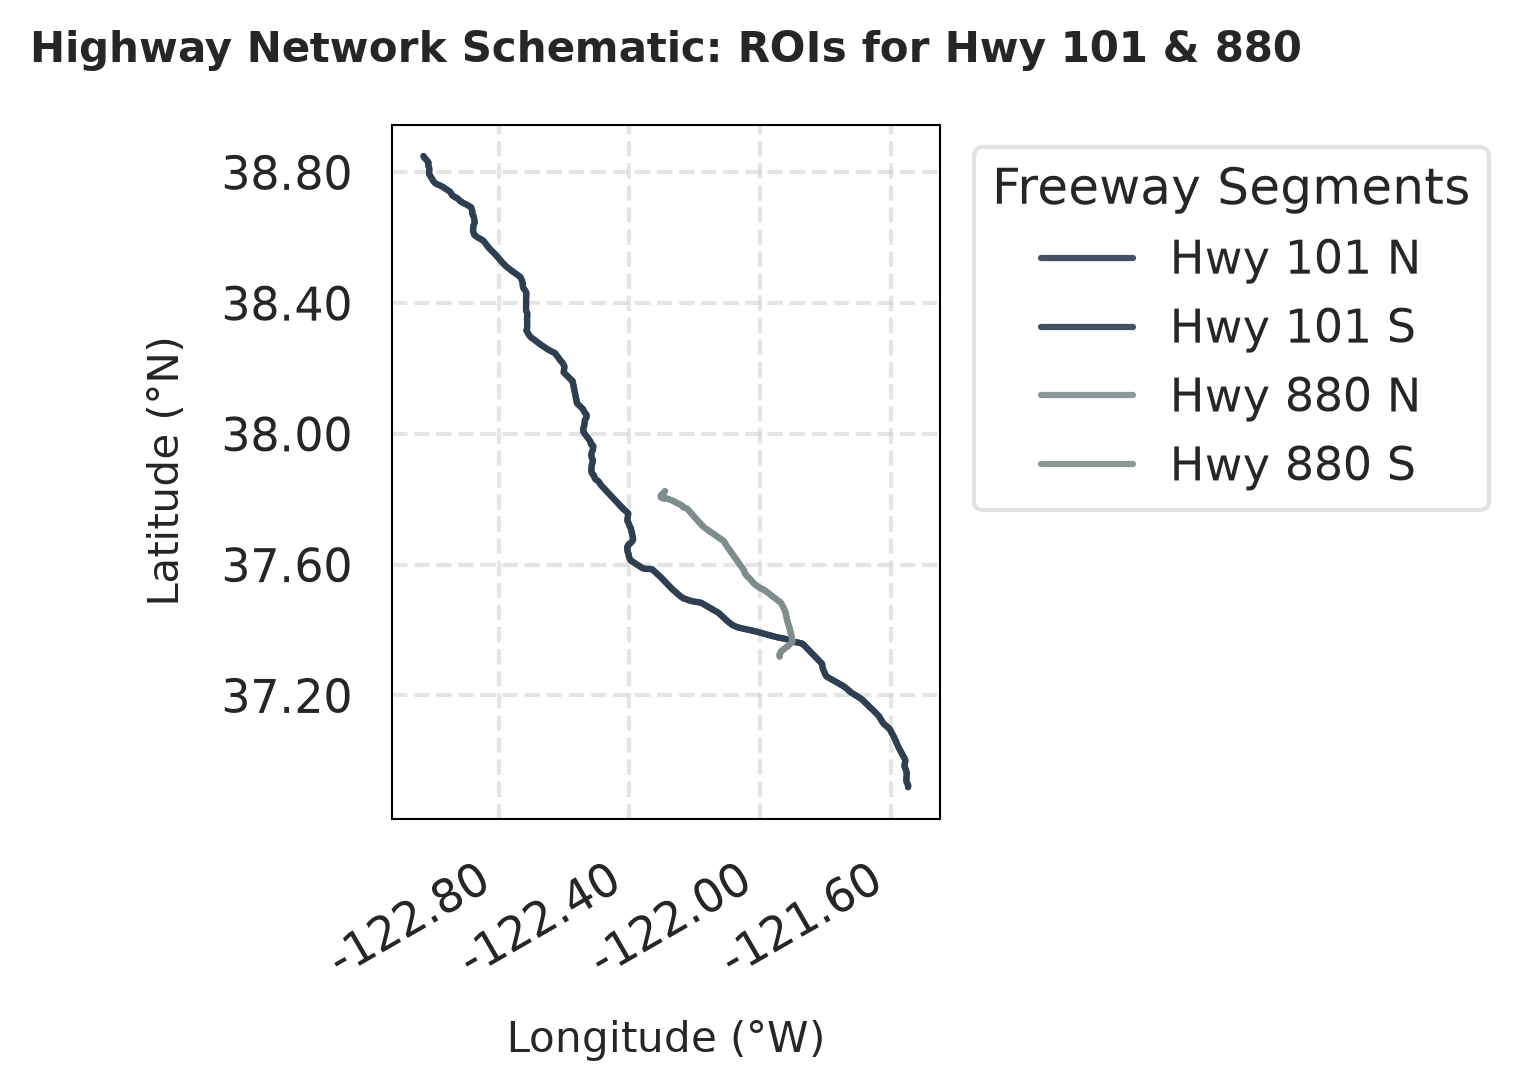

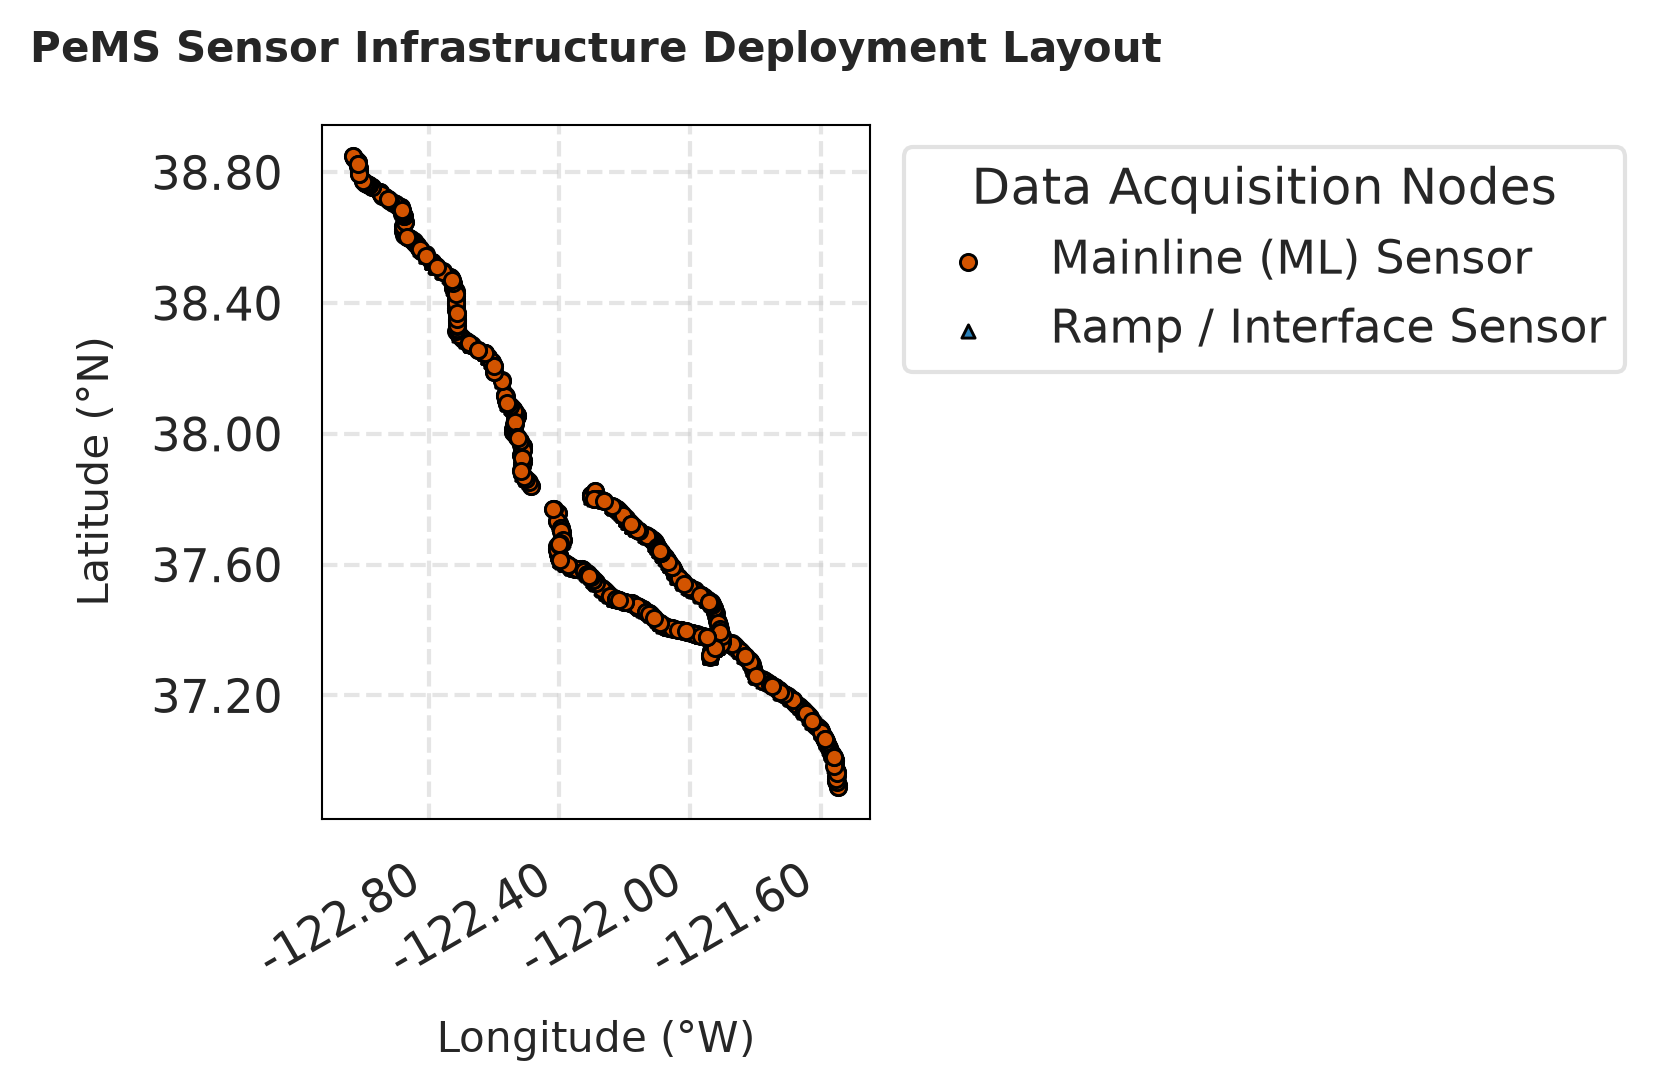

In [32]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "black", "axes.linewidth": 0.5})

FWY_COLORS = {101: '#2c3e50', 880: '#7f8c8d'}
SENSOR_COLORS = {'ML': '#d35400', 'Ramp': '#2980b9'}

def format_academic_map_axes(ax, title, bbox_padding=0.05):
    ax.set_title(title, fontsize=10, fontweight='bold', pad=15)
    ax.set_xlabel("Longitude (°W)", fontsize=10, labelpad=8)
    ax.set_ylabel("Latitude (°N)", fontsize=10, labelpad=8)
    ax.grid(True, linestyle='--', alpha=0.5, color='#cccccc', zorder=0)
    ax.set_aspect('equal', adjustable='box')
    
    lat_range = freeway_of_interest_df['Latitude'].max() - freeway_of_interest_df['Latitude'].min()
    lon_range = freeway_of_interest_df['Longitude'].max() - freeway_of_interest_df['Longitude'].min()
    padding = max(lat_range, lon_range) * bbox_padding
    ax.set_ylim(freeway_of_interest_df['Latitude'].min() - padding, freeway_of_interest_df['Latitude'].max() + padding)
    ax.set_xlim(freeway_of_interest_df['Longitude'].min() - padding, freeway_of_interest_df['Longitude'].max() + padding)
    
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=6)) 

    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
    
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

fig1, ax1 = plt.subplots(figsize=(6.5, 3.8), dpi=300)


for (fwy, direction), group in freeway_of_interest_df.groupby(['Fwy', 'Dir']):
    sorted_group = group.sort_values(by='Abs_PM')
    label_text = f"Hwy {fwy} {direction}"
    ax1.plot(
        sorted_group['Longitude'],
        sorted_group['Latitude'],
        color=FWY_COLORS.get(fwy, 'gray'),
        linewidth=1.5,
        alpha=0.9,
        label=label_text,
        zorder=1
    )

format_academic_map_axes(ax1, "Highway Network Schematic: ROIs for Hwy 101 & 880")
ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1),  frameon=True, facecolor='white', edgecolor='#e2e2e2', framealpha=1, title="Freeway Segments")
plt.tight_layout()
plt.savefig('scientific_roads_map.pdf', bbox_inches='tight')
plt.savefig('scientific_roads_map.png', bbox_inches='tight', dpi=300)

fig2, ax2 = plt.subplots(figsize=(6.5, 3.8), dpi=300)
ml_sensors = freeway_of_interest_df[freeway_of_interest_df['Type'] == 'ML']
ramp_sensors = freeway_of_interest_df[freeway_of_interest_df['Type'] != 'ML']

ax2.scatter(
    ml_sensors['Longitude'], ml_sensors['Latitude'], 
    color=SENSOR_COLORS['ML'], s=15, marker='o', edgecolors='black', linewidths=0.7, label='Mainline (ML) Sensor', zorder=3
)
ax2.scatter(
    ramp_sensors['Longitude'], ramp_sensors['Latitude'], 
    color=SENSOR_COLORS['Ramp'], s=10, marker='^', edgecolors='black', linewidths=0.7, label='Ramp / Interface Sensor', zorder=2
)
format_academic_map_axes(ax2, "PeMS Sensor Infrastructure Deployment Layout")
ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True, facecolor='white', edgecolor='#e2e2e2', framealpha=1, title="Data Acquisition Nodes")
plt.tight_layout()
plt.savefig('scientific_sensor_map.pdf', bbox_inches='tight')
plt.savefig('scientific_sensor_map.png', bbox_inches='tight', dpi=300)

print("\nDone. Maps generated successfully:")
print("1. scientific_roads_map.pdf/.png (Pure Infrastructure)")
print("2. scientific_sensor_map.pdf/.png (Pure Sensor Nodes)")
plt.show()

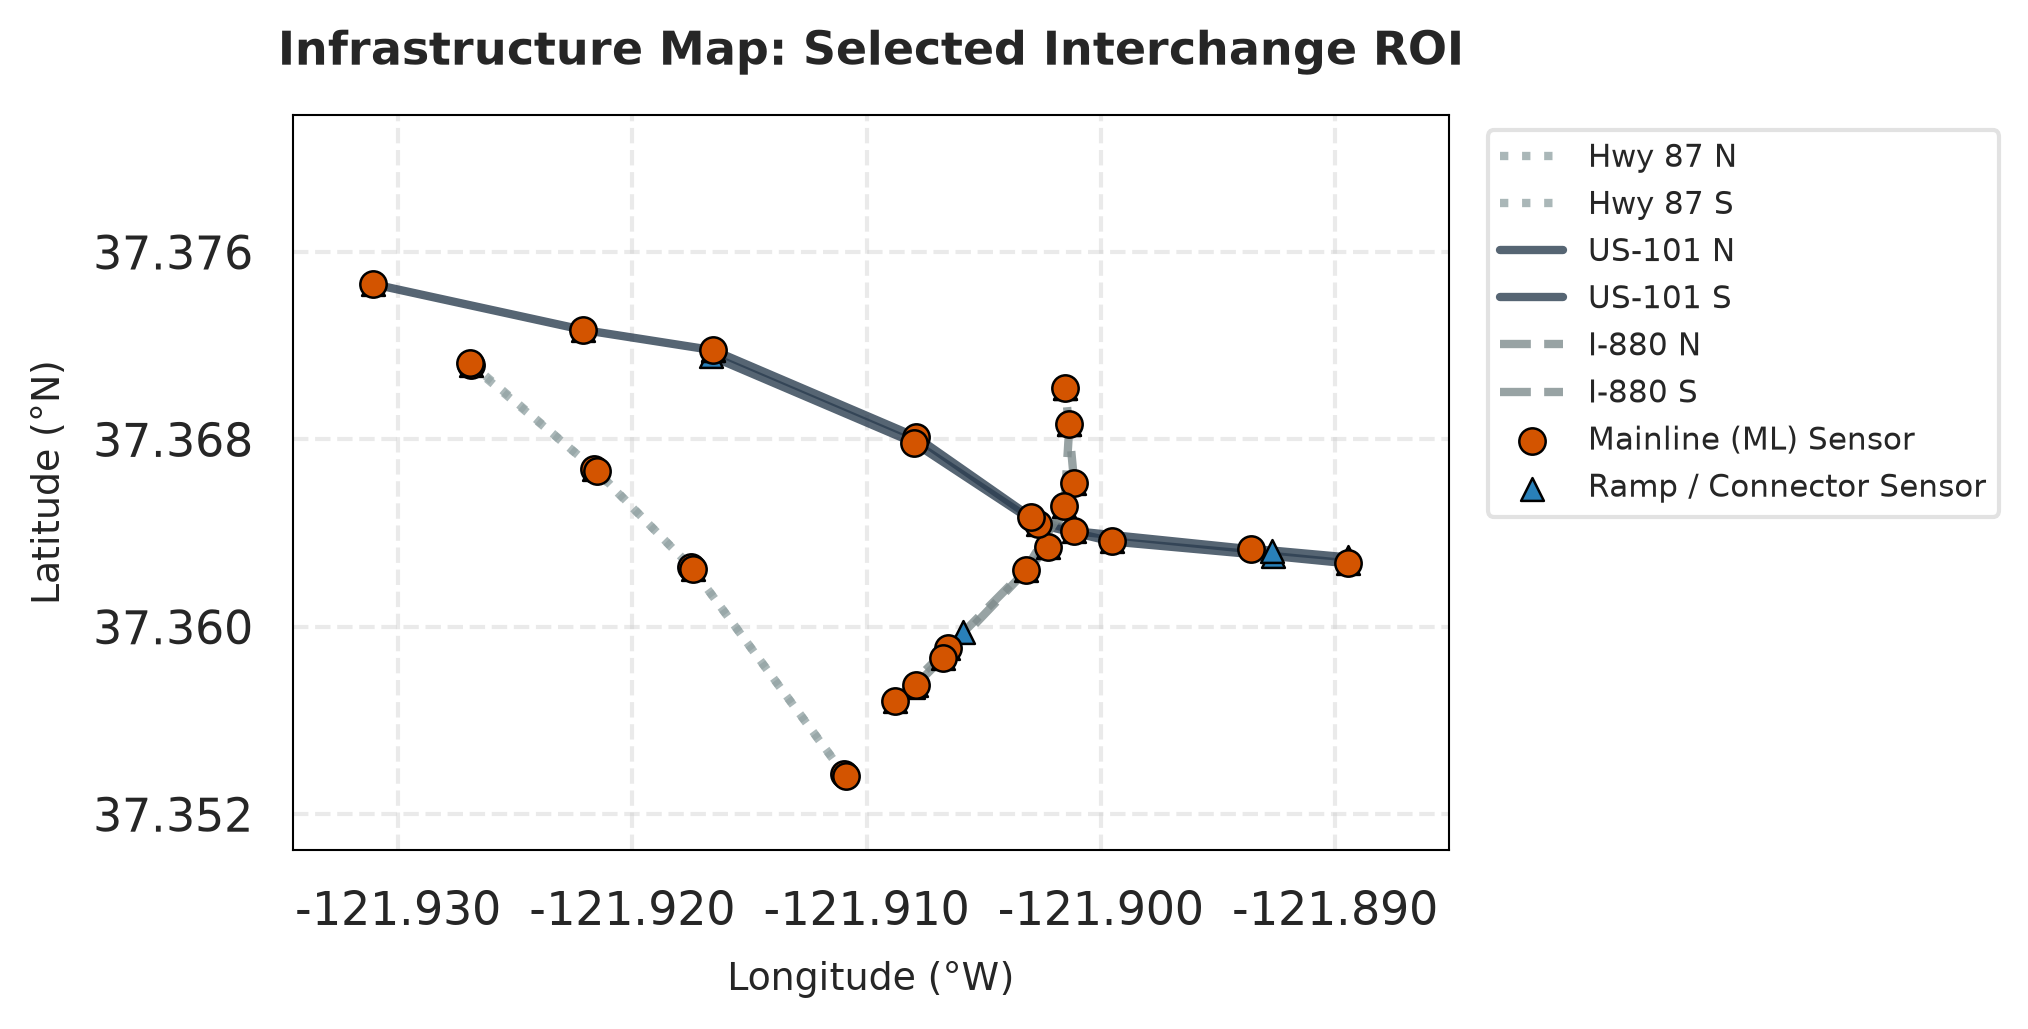

In [27]:
lat_min = 37.3534550567675 
long_min = -121.93150052135863
lat_max = 37.378862007437284
long_max = -121.88812513240218

intersection_df = st_mtdta_df[
    (st_mtdta_df['Latitude'] >= lat_min) & (st_mtdta_df['Latitude'] <= lat_max) &
    (st_mtdta_df['Longitude'] >= long_min) & (st_mtdta_df['Longitude'] <= long_max)
].copy()

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 7
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "black", "axes.linewidth": 0.5})

fig, ax = plt.subplots(figsize=(6.5, 3.8), dpi=300)
fwy_styles = {
    101: {'color': '#2c3e50', 'linestyle': '-', 'label_prefix': 'US-101'},
    880: {'color': '#7f8c8d', 'linestyle': '--', 'label_prefix': 'I-880'}
}

for (fwy, direction), group in intersection_df.groupby(['Fwy', 'Dir']):
    sorted_group = group.sort_values(by='Abs_PM')
    style = fwy_styles.get(fwy, {'color': '#95a5a6', 'linestyle': ':', 'label_prefix': f'Hwy {fwy}'})
    
    ax.plot(
        sorted_group['Longitude'], 
        sorted_group['Latitude'], 
        color=style['color'],
        linestyle=style['linestyle'],
        linewidth=2.0,
        alpha=0.8,
        zorder=1,
        label=f"{style['label_prefix']} {direction}"
    )

ml_sensors = intersection_df[intersection_df['Type'] == 'ML']
ramp_sensors = intersection_df[intersection_df['Type'] != 'ML']

ax.scatter(
    ml_sensors['Longitude'], ml_sensors['Latitude'], 
    color='#d35400', s=40, marker='o', edgecolors='black', 
    linewidths=0.6, label='Mainline (ML) Sensor', zorder=3
)
ax.scatter(
    ramp_sensors['Longitude'], ramp_sensors['Latitude'], 
    color='#2980b9', s=30, marker='^', edgecolors='black', 
    linewidths=0.6, label='Ramp / Connector Sensor', zorder=2
)
  
ax.set_title("Infrastructure Map: Selected Interchange ROI", fontsize=11, fontweight='bold', pad=12)
ax.set_xlabel("Longitude (°W)", fontsize=9, labelpad=6)
ax.set_ylabel("Latitude (°N)", fontsize=9, labelpad=6)

pad = 0.003
ax.set_xlim(long_min - pad, long_max + pad)
ax.set_ylim(lat_min - pad, lat_max + pad)
ax.grid(True, linestyle='--', alpha=0.4, color='#cccccc', zorder=0)
ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f')) # 3 decimals for close zoom
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
ax.set_aspect('equal', adjustable='box')
ax.legend(
    loc='upper left', 
    bbox_to_anchor=(1.02, 1), 
    frameon=True, 
    facecolor='white', 
    edgecolor='#e2e2e2', 
    fontsize=7.5, 
    framealpha=1
)
plt.tight_layout()
plt.savefig('intersection_roi_map.png', bbox_inches='tight', dpi=300)
plt.savefig('intersection_roi_map.pdf', bbox_inches='tight')
plt.show()

In [36]:
# region of interest
lat_min = 37.3534550567675 
long_min = -121.93150052135863
lat_max = 37.378862007437284
long_max = -121.88812513240218

region_df = st_mtdta_df[
    (st_mtdta_df['Latitude']>=lat_min) & (st_mtdta_df['Latitude']<=lat_max) &
    (st_mtdta_df['Longitude']>=long_min) & (st_mtdta_df['Longitude']<=long_max)
].copy()

print(len(region_df), " Number of stations in this region.") # 58 stations in this region
region_df.head()

58  Number of stations in this region.


,ID,Fwy,Dir,District,County,City,State_PM,Abs_PM,Latitude,Longitude,Length,Type,Lanes,Name,User_ID_1,User_ID_2,User_ID_3,User_ID_4
1,400001,101,N,4,85,68000.0,38.26,387.897,37.364085,-121.901149,0.265,ML,5,NB 880 rm-n-loop,DT697,L5-N-37-101-03826,998145,426518
14,400030,880,S,4,85,68000.0,3.64,3.640,37.359087,-121.906538,0.250,ML,4,N First St rm-s-loop,DT969,L4-S-37-880-00364,880130,421412
22,400045,880,N,4,85,68000.0,4.02,4.020,37.363402,-121.902233,0.300,ML,4,SB 101 rm-n-loop,DT974,L4-N-37-880-00402,998313,421007
60,400109,101,S,4,85,68000.0,37.61,387.283,37.362706,-121.889426,0.785,ML,4,N 13th St/Oakland Rd rm-s-diag,DT027,L4-S-37-101-03761,998139,424540
69,400122,880,N,4,85,68000.0,4.21,4.210,37.366140,-121.901132,0.240,ML,3,NB 101 rm-n-diag,DT975,L3-N-37-880-00421,998317,421012


In [37]:
# finding stations in interchange, simple approach using name discription
interchange_rows_101 = region_df[
    (region_df["Fwy"] == 101) & 
    (region_df["Name"].str.contains('880'))
]
print("Interchange stations matching from US-101 to US-880:")
print(interchange_rows_101[['ID', 'Name', 'Type', 'Abs_PM', 'Latitude', 'Longitude']])

interchange_rows_880 = region_df[
    (region_df["Fwy"] == 880) & 
    (region_df["Name"].str.contains('101'))
]
print("Interchange stations matching from US-880 to US-101:")
print(interchange_rows_880[['ID', 'Name', 'Type', 'Abs_PM', 'Latitude', 'Longitude']])

Interchange stations matching from US-101 to US-880:
          ID              Name Type   Abs_PM   Latitude   Longitude
1     400001  NB 880 rm-n-loop   ML  387.897  37.364085 -121.901149
223   400394  SB 880 rm-s-loop   ML  388.023  37.364382 -121.902692
517   400922  NB 880 rm-s-diag   ML  387.843  37.363644 -121.899535
2533  408404    NB 880 on loop   OR  387.897  37.364085 -121.901149
2534  408410    SB 880 on loop   OR  388.023  37.364382 -121.902692
2535  408411    NB 880 on diag   OR  387.843  37.363644 -121.899535
Interchange stations matching from US-880 to US-101:
          ID              Name Type  Abs_PM   Latitude   Longitude
22    400045  SB 101 rm-n-loop   ML    4.02  37.363402 -121.902233
69    400122  NB 101 rm-n-diag   ML    4.21  37.366140 -121.901132
274   400479  SB 101 rm-s-diag   ML    3.94  37.362439 -121.903211
1978  404759  NB 101 rm-s-loop   ML    4.13  37.365167 -121.901551
2536  408437    SB 101 on loop   OR    4.02  37.363402 -121.902233
2537  408438    

In [38]:
min_101 = interchange_rows_101["Abs_PM"].min()
max_101 = interchange_rows_101["Abs_PM"].max()

min_880 = interchange_rows_880["Abs_PM"].min()
max_880 = interchange_rows_880["Abs_PM"].max()

# to how extent we capture the upstream and downstream
buffer = 1.5

# 101 Corridors
ml_101 = region_df[ (region_df["Fwy"] == 101) & (region_df['Type'] == "ML")]

# US-101 Northbound (Traffic moves lower to higher postmiles)
u_101_nb = ml_101[
    (ml_101['Dir'] == 'N') & 
    (ml_101['Abs_PM'] >= min_101-buffer) & 
    (ml_101['Abs_PM'] < min_101)
].sort_values('Abs_PM', ascending=True)

d_101_nb = ml_101[
    (ml_101['Dir'] == 'N') & 
    (ml_101['Abs_PM'] > max_101) & 
    (ml_101['Abs_PM'] <= max_101+buffer)
].sort_values('Abs_PM', ascending=True)

# US-101 Southbound (Traffic moves higher to lower postmiles)
u_101_sb = ml_101[
    (ml_101['Dir'] == 'S') & 
    (ml_101['Abs_PM'] > max_101) & 
    (ml_101['Abs_PM'] <= max_101+buffer)
].sort_values('Abs_PM', ascending=False)
d_101_sb = ml_101[
    (ml_101['Dir'] == 'S') & 
    (ml_101['Abs_PM'] >= min_101-buffer) & 
    (ml_101['Abs_PM'] < min_101)
].sort_values('Abs_PM', ascending=False)

# 880 Corridors
ml_880 = region_df[(region_df["Fwy"] == 880) & (region_df['Type'] == "ML")]

# I-880 Northbound (Traffic moves lower to higher postmiles)
u_880_nb = ml_880[
    (ml_880["Dir"] == 'N') & 
    (ml_880["Abs_PM"] >= min_880-buffer) &
    (ml_880["Abs_PM"] < min_880)
].sort_values("Abs_PM", ascending=True)
d_880_nb = ml_880[
    (ml_880["Dir"] == 'N') & 
    (ml_880["Abs_PM"] > max_880) &
    (ml_880["Abs_PM"] <= max_880+buffer)
].sort_values("Abs_PM", ascending=True)

# I-880 Southbound (Traffic moves higher to lower postmiles)
u_880_sb = ml_880[
    (ml_880["Dir"] == 'S') & 
    (ml_880["Abs_PM"] > max_880) &
    (ml_880["Abs_PM"] <= max_880+buffer)
].sort_values("Abs_PM", ascending=False)
d_880_sb = ml_880[
    (ml_880["Dir"] == 'S') & 
    (ml_880["Abs_PM"] >= min_880-buffer) &
    (ml_880["Abs_PM"] < min_880)
].sort_values("Abs_PM", ascending=False)

In [41]:
print("Up 880 S\n", u_880_sb[['ID', 'Name', 'Abs_PM']])
print("Dn 880 S\n",d_880_sb[['ID', 'Name', 'Abs_PM']])
print("Up 880 N\n",u_880_nb[['ID', 'Name', 'Abs_PM']])
print("Dn 880 N\n", d_880_nb[['ID', 'Name', 'Abs_PM']])

print("Up 101 S\n", u_101_sb[['ID', 'Name', 'Abs_PM']])
print("Dn 101 S\n", d_101_sb[['ID', 'Name', 'Abs_PM']])
print("Up 101 N\n", u_101_nb[['ID', 'Name', 'Abs_PM']])
print("Dn 101 N\n", d_101_nb[['ID', 'Name', 'Abs_PM']])

Up 880 S
          ID              Name  Abs_PM
543  400971  Old Bayshore Hwy    4.39
Dn 880 S
          ID                  Name  Abs_PM
14   400030  N First St rm-s-loop    3.64
704  401440  N First St rm-s-diag    3.44
Up 880 N
           ID                Name  Abs_PM
768   401560    1st St rm-n-loop    3.51
3463  422357  N 1st St rm-n-diag    3.61
Dn 880 N
          ID               Name  Abs_PM
758  401541  Gish Rd rm-n-diag     4.5
Up 101 S
           ID           Name   Abs_PM
1176  402365  4A5324 loc 66  388.403
Dn 101 S
         ID                            Name   Abs_PM
60  400109  N 13th St/Oakland Rd rm-s-diag  387.283
Up 101 N
          ID                  Name   Abs_PM
541  400965  Oakland Rd rm-n-diag  387.477
Dn 101 N
           ID                 Name   Abs_PM
1175  402364        4A5324 loc 66  388.367
495   400863   N 1st St rm-n-loop  388.917
515   400911  Brokaw Rd rm-n-diag  389.227


In [42]:
# Condensing logic into a function for reuseability
def get_stations_near_roi(
    st_mtdta_df: pd.DataFrame,
    lat_min=37.353455, lat_max=37.378862,
    long_min=-121.931501, long_max=-121.888125,
    fwy_a=101, fwy_b=880, buffer=1.5
):
    """
    gets stations upstream and downstream of an interchanges in a region of interest
    """
    region_df = st_mtdta_df[
        (st_mtdta_df['Latitude']>=lat_min) & (st_mtdta_df['Latitude']<=lat_max) &
        (st_mtdta_df['Longitude']>=long_min) & (st_mtdta_df['Longitude']<=long_max)
    ].copy()
    
    print(len(region_df), " Number of stations in this region.") # 58 stations in this region

    # finding stations in interchange, simple approach using name discription
    interchange_rows_a = region_df[(region_df["Fwy"] == fwy_a) & (region_df["Name"].str.contains(str(fwy_b)))]
    interchange_rows_b = region_df[(region_df["Fwy"] == fwy_b) & (region_df["Name"].str.contains(str(fwy_a)))]
    
    min_a, max_a = interchange_rows_a["Abs_PM"].min(), interchange_rows_a["Abs_PM"].max()
    min_b, max_b = interchange_rows_b["Abs_PM"].min(), interchange_rows_b["Abs_PM"].max()
    
    # Main corridors
    ml_a = region_df[(region_df["Fwy"] == fwy_a) & (region_df['Type'] == "ML")]
    ml_b = region_df[(region_df["Fwy"] == fwy_b) & (region_df['Type'] == "ML")] 
    
    u_a_nb = ml_a[(ml_a['Dir'] == 'N') & (ml_a['Abs_PM'] >= min_a - buffer) & (ml_a['Abs_PM'] < min_a)].sort_values('Abs_PM', ascending=True)
    d_a_nb = ml_a[(ml_a['Dir'] == 'N') & (ml_a['Abs_PM'] > max_a) & (ml_a['Abs_PM'] <= max_a + buffer)].sort_values('Abs_PM', ascending=True)
    
    u_a_sb = ml_a[(ml_a['Dir'] == 'S') & (ml_a['Abs_PM'] > max_a) & (ml_a['Abs_PM'] <= max_a + buffer)].sort_values('Abs_PM', ascending=False)
    d_a_sb = ml_a[(ml_a['Dir'] == 'S') & (ml_a['Abs_PM'] >= min_a - buffer) & (ml_a['Abs_PM'] < min_a)].sort_values('Abs_PM', ascending=False)
    
    
    u_b_nb = ml_b[(ml_b["Dir"] == 'N') & (ml_b['Abs_PM'] >= min_b - buffer) & (ml_b['Abs_PM'] < min_b)].sort_values('Abs_PM', ascending=True)
    d_b_nb = ml_b[(ml_b["Dir"] == 'N') & (ml_b['Abs_PM'] > max_b) & (ml_b['Abs_PM'] <= max_b + buffer)].sort_values('Abs_PM', ascending=True)
    
    u_b_sb = ml_b[(ml_b["Dir"] == 'S') & (ml_b['Abs_PM'] > max_b) & (ml_b['Abs_PM'] <= max_b + buffer)].sort_values('Abs_PM', ascending=False)
    d_b_sb = ml_b[(ml_b["Dir"] == 'S') & (ml_b['Abs_PM'] >= min_b - buffer) & (ml_b['Abs_PM'] < min_b)].sort_values('Abs_PM', ascending=False)

    # 4. Package into an organized dictionary
    results = {
        f"{fwy_a}_NB_upstream": u_a_nb,
        f"{fwy_a}_NB_downstream": d_a_nb,
        f"{fwy_a}_SB_upstream": u_a_sb,
        f"{fwy_a}_SB_downstream": d_a_sb,
        f"{fwy_b}_NB_upstream": u_b_nb,
        f"{fwy_b}_NB_downstream": d_b_nb,
        f"{fwy_b}_SB_upstream": u_b_sb,
        f"{fwy_b}_SB_downstream": d_b_sb
    }

    return results

In [43]:
corridors = get_stations_near_roi(st_mtdta_df=st_mtdta_df)
upstream_101_nb_ids = corridors['101_NB_upstream']['ID'].tolist()
upstream_101_sb_ids = corridors['101_SB_upstream']['ID'].tolist()
downstream_101_nb_ids = corridors['101_NB_downstream']['ID'].tolist()
downstream_101_sb_ids = corridors['101_SB_downstream']['ID'].tolist()

upstream_880_nb_ids = corridors['880_NB_upstream']['ID'].tolist()
upstream_880_sb_ids = corridors['880_SB_upstream']['ID'].tolist()
downstream_880_nb_ids = corridors['880_NB_downstream']['ID'].tolist()
downstream_880_sb_ids = corridors['880_SB_downstream']['ID'].tolist()

print("Stations to query:", upstream_101_nb_ids)
print("Stations to query:", upstream_101_sb_ids)
print("Stations to query:", downstream_101_nb_ids)
print("Stations to query:", downstream_101_sb_ids)
print("Stations to query:", upstream_880_nb_ids)
print("Stations to query:", upstream_880_sb_ids)
print("Stations to query:", downstream_880_nb_ids)
print("Stations to query:", downstream_880_sb_ids)

58  Number of stations in this region.
Stations to query: [400965]
Stations to query: [402365]
Stations to query: [402364, 400863, 400911]
Stations to query: [400109]
Stations to query: [401560, 422357]
Stations to query: [400971]
Stations to query: [401541]
Stations to query: [400030, 401440]


In [44]:
furthest_stations = {}

for corridor_key, corridor_df in corridors.items():
    if corridor_df.empty:
        print(f"Skipping {corridor_key}: No mainline stations present in this buffer zone.")
        continue

    if "upstream" in corridor_key:
        furthest_row = corridor_df.iloc[0]   # First row is the outer boundary entry point
    elif "downstream" in corridor_key:
        furthest_row = corridor_df.iloc[-1]  # Last row is the outer boundary exit point

    furthest_stations[corridor_key] = {
        'ID': int(furthest_row['ID']),
        'Abs_PM': furthest_row['Abs_PM'],
        'Name': furthest_row['Name'],
        'Lanes': furthest_row['Lanes']
    }
print("\n=== Outer Boundary Stations Relative to Interchange ===")
for key, info in furthest_stations.items():
    print(f"{key.upper():<25} -> ID: {info['ID']:<7} | Abs_PM: {info['Abs_PM']:<6.2f} | {info['Name']}")  


=== Outer Boundary Stations Relative to Interchange ===
101_NB_UPSTREAM           -> ID: 400965  | Abs_PM: 387.48 | Oakland Rd rm-n-diag
101_NB_DOWNSTREAM         -> ID: 400911  | Abs_PM: 389.23 | Brokaw Rd rm-n-diag
101_SB_UPSTREAM           -> ID: 402365  | Abs_PM: 388.40 | 4A5324 loc 66
101_SB_DOWNSTREAM         -> ID: 400109  | Abs_PM: 387.28 | N 13th St/Oakland Rd rm-s-diag
880_NB_UPSTREAM           -> ID: 401560  | Abs_PM: 3.51   | 1st St rm-n-loop
880_NB_DOWNSTREAM         -> ID: 401541  | Abs_PM: 4.50   | Gish Rd rm-n-diag
880_SB_UPSTREAM           -> ID: 400971  | Abs_PM: 4.39   | Old Bayshore Hwy
880_SB_DOWNSTREAM         -> ID: 401440  | Abs_PM: 3.44   | N First St rm-s-diag
